# Real Estate Energy Intensity Estimation & Predictive Modeling

##### Inefficient energy consumption in residential and commercial buildings drives up operational expenditures for both real estate developers and property owners. This project implements an Exploratory Data Analysis (EDA) workflow to uncover the underlying drivers of energy inefficiencies, followed by the development of a robust Supervised Machine Learning pipeline designed to forecast building energy consumption metrics with high predictive accuracy.
##### We will work with a dataset containing features related to the energy consumption of buildings in the United States. We will start by performing an exploratory data analysis, and subsequently train a machine learning model capable of accurately predicting a building's energy expenditure.

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 100

In [40]:
df = pd.read_csv("data.csv")
print(f"Dataset dimensions: {df.shape[0]} rows y {df.shape[1]} columns.")
df.head()

Dataset dimensions: 75757 rows y 64 columns.


,Year_Factor,State_Factor,building_class,facility_type,floor_area,year_built,energy_star_rating,ELEVATION,january_min_temp,january_avg_temp,...,days_above_80F,days_above_90F,days_above_100F,days_above_110F,direction_max_wind_speed,direction_peak_wind_speed,max_wind_speed,days_with_fog,site_eui,id
0,1,State_1,Commercial,Grocery_store_or_food_market,61242.0,1942.0,11.0,2.4,36,50.5,...,14,0,0,0,1.0,1.0,1.0,NaN,248.682615,0
1,1,State_1,Commercial,Warehouse_Distribution_or_Shipping_center,274000.0,1955.0,45.0,1.8,36,50.5,...,14,0,0,0,1.0,NaN,1.0,12.0,26.500150,1
2,1,State_1,Commercial,Retail_Enclosed_mall,280025.0,1951.0,97.0,1.8,36,50.5,...,14,0,0,0,1.0,NaN,1.0,12.0,24.693619,2
3,1,State_1,Commercial,Education_Other_classroom,55325.0,1980.0,46.0,1.8,36,50.5,...,14,0,0,0,1.0,NaN,1.0,12.0,48.406926,3
4,1,State_1,Commercial,Warehouse_Nonrefrigerated,66000.0,1985.0,100.0,2.4,36,50.5,...,14,0,0,0,1.0,1.0,1.0,NaN,3.899395,4


## 1. Exploratory Data Analysis (EDA)

In [41]:
df.describe().T[['count', 'mean', 'std', 'min', '50%', 'max']]

,count,mean,std,min,50%,max
Year_Factor,75757.0,4.367755,1.471441,1.000000,5.000000,6.000000e+00
floor_area,75757.0,165983.865858,246875.790940,943.000000,91367.000000,6.385382e+06
year_built,73920.0,1952.306764,37.053619,0.000000,1951.000000,2.015000e+03
energy_star_rating,49048.0,61.048605,28.663683,0.000000,67.000000,1.000000e+02
ELEVATION,75757.0,39.506323,60.656596,-6.400000,25.000000,1.924500e+03
...,...,...,...,...,...,...
direction_peak_wind_speed,33946.0,62.779974,130.308106,1.000000,1.000000,3.600000e+02
max_wind_speed,34675.0,4.190601,6.458789,1.000000,1.000000,2.330000e+01
days_with_fog,29961.0,109.142051,50.699751,12.000000,104.000000,3.110000e+02
site_eui,75757.0,82.584693,58.255403,1.001169,75.293716,9.978661e+02


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75757 entries, 0 to 75756
Data columns (total 64 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Year_Factor                75757 non-null  int64  
 1   State_Factor               75757 non-null  object 
 2   building_class             75757 non-null  object 
 3   facility_type              75757 non-null  object 
 4   floor_area                 75757 non-null  float64
 5   year_built                 73920 non-null  float64
 6   energy_star_rating         49048 non-null  float64
 7   ELEVATION                  75757 non-null  float64
 8   january_min_temp           75757 non-null  int64  
 9   january_avg_temp           75757 non-null  float64
 10  january_max_temp           75757 non-null  int64  
 11  february_min_temp          75757 non-null  int64  
 12  february_avg_temp          75757 non-null  float64
 13  february_max_temp          75757 non-null  int

The dataset comprises 75,757 observations across 63 features. A substantial portion of these variables correspond to monthly meteorological records, requiring systematic aggregation to optimize model performance.

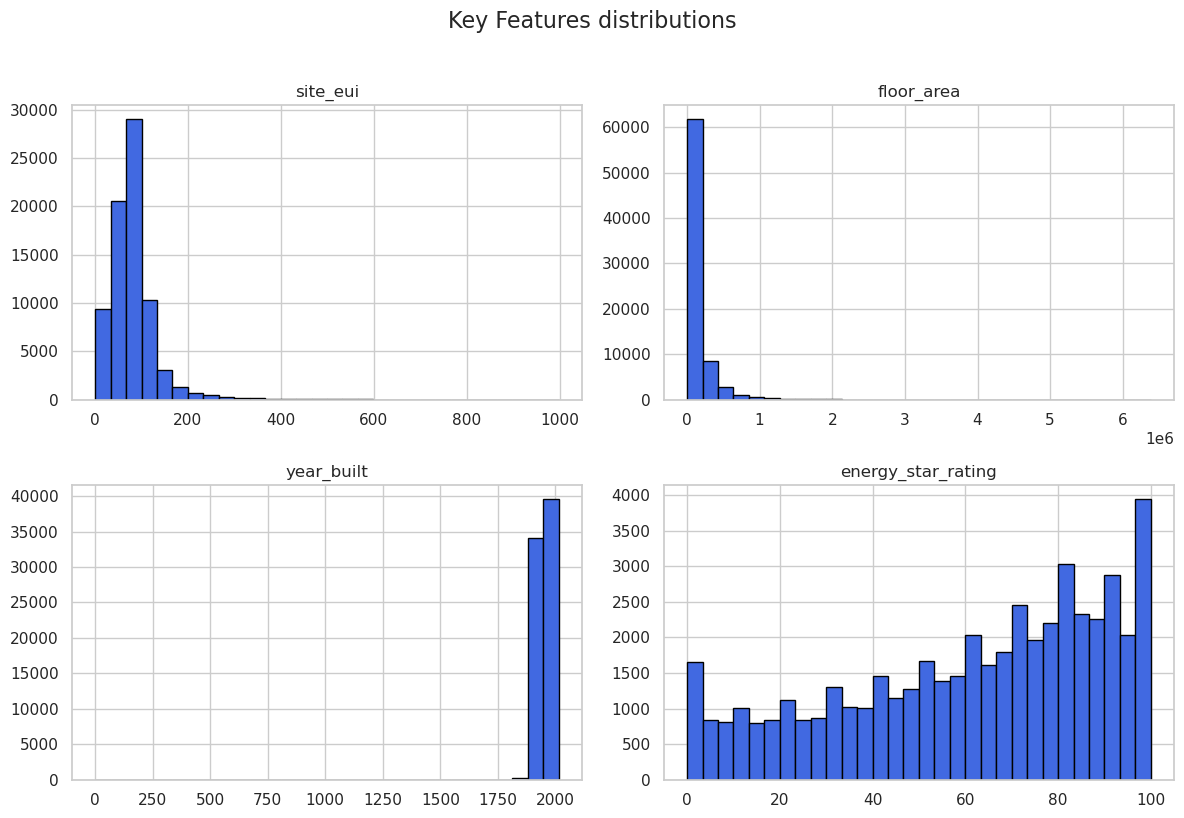

In [43]:
key_features = ['site_eui', 'floor_area', 'year_built', 'energy_star_rating']
df[key_features].hist(figsize=(12, 8), bins=30, color='royalblue', edgecolor='black')
plt.suptitle('Key Features distributions', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

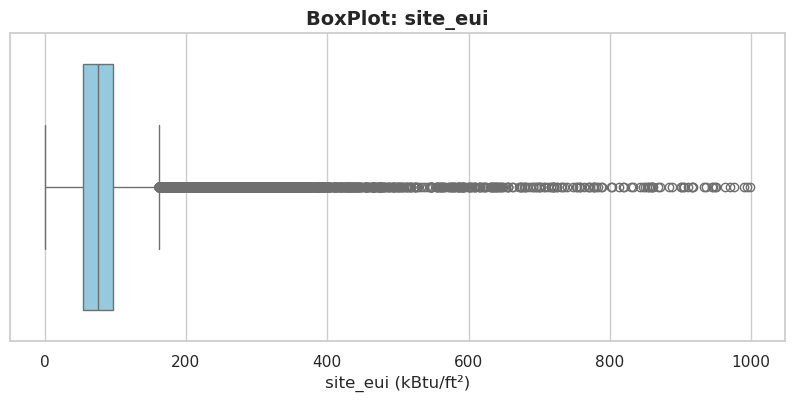

In [44]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df["site_eui"], color='skyblue')
plt.title('BoxPlot: site_eui', fontsize=14, fontweight='bold')
plt.xlabel('site_eui (kBtu/ft²)', fontsize=12)
plt.show()

COUNT     : 75,757.00
MEAN      : 82.58
STD       : 58.26
MIN       : 1.00
25%       : 54.53
MEDIAN    : 75.29
75%       : 97.28
MAX       : 997.87
SKEW      : 4.74


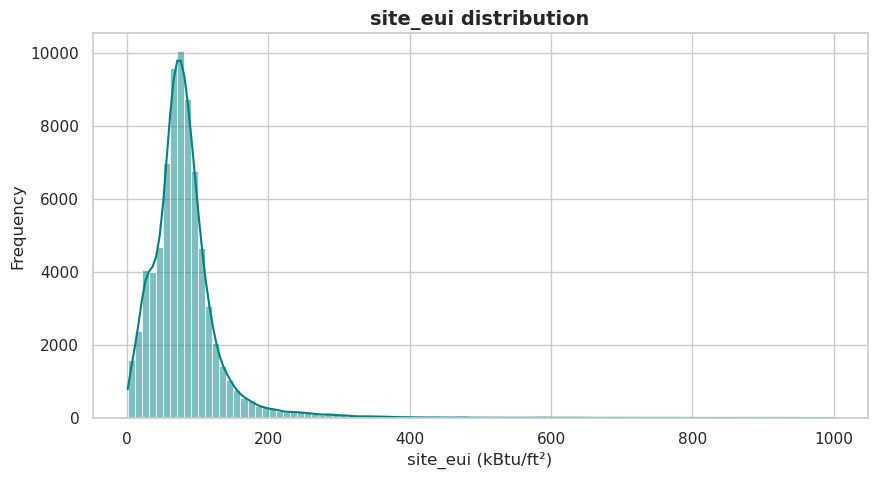

In [45]:
target = df['site_eui']
stats = {
    'count': target.count(),
    'mean': target.mean(),
    'std': target.std(),
    'min': target.min(),
    '25%': target.quantile(0.25),
    'median': target.median(),
    '75%': target.quantile(0.75),
    'max': target.max(),
    'skew': target.skew()
}

for k, v in stats.items():
    print(f"{k.upper():<10}: {v:,.2f}")

plt.figure(figsize=(10, 5))
sns.histplot(target, bins=100, kde=True, color='teal')
plt.title('site_eui distribution', fontsize=14, fontweight='bold')
plt.xlabel('site_eui (kBtu/ft²)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

A high variance and significant positive skewness are observed in the distribution of the target variable. We will address this later using a logarithmic transformation within our modeling pipeline.

## 2. Feature Engineering & Data Preprocessing

We filter rows with missing construction years and engineer a new feature representing the building's effective age.

In [46]:
df = df.dropna(subset=['year_built'])

In [47]:
df["building_age"] = 2026 - df["Year_Factor"] - df["year_built"]
df = df.drop(columns=["year_built", "Year_Factor"])

Imputation of missing values in `energy_star_rating` using the median value grouped by building facility type.

In [48]:
df['energy_star_rating'] = df['energy_star_rating'].fillna(
    df.groupby('facility_type')['energy_star_rating'].transform('median')
)

In [49]:
df = df.dropna(subset=['energy_star_rating'])

Removal of non-informative identifiers.

In [50]:
df = df.drop(columns=["id"], errors='ignore')

Encoding categorical features into numerical formats.

In [51]:
df['building_class'] = df['building_class'].map({'Commercial': 1, 'Residential': 0})

In [52]:
from category_encoders import TargetEncoder

encoder_facility = TargetEncoder(cols=['facility_type'])
encoder_state = TargetEncoder(cols=['State_Factor'])

df['facility_type'] = encoder_facility.fit_transform(df['facility_type'], df['site_eui'])
df['State_Factor'] = encoder_state.fit_transform(df['State_Factor'], df['site_eui'])

Dropping low-variance wind and weather features to avoid noise.

In [53]:
cols_to_drop = ["direction_max_wind_speed", "direction_peak_wind_speed", "max_wind_speed", "days_with_fog"]
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns], errors='ignore')

Aggregating monthly meteorological variables into seasonal indexes to mitigate multicollinearity.

In [54]:
media_meses_invierno = ['december_avg_temp', 'january_avg_temp', 'february_avg_temp']
max_meses_invierno = ['december_max_temp', 'january_max_temp', 'february_max_temp']
min_meses_invierno = ['december_min_temp', 'january_min_temp', 'february_min_temp']

df["winter_mean"] = df[media_meses_invierno].mean(axis=1)
df["winter_max"] = df[max_meses_invierno].mean(axis=1)
df["winter_min"] = df[min_meses_invierno].mean(axis=1)

media_meses_primavera = ['march_avg_temp', 'april_avg_temp', 'may_avg_temp']
max_meses_primavera = ['march_max_temp', 'april_max_temp', 'may_max_temp']
min_meses_primavera = ['march_min_temp', 'april_min_temp', 'may_min_temp']

df["spring_mean"] = df[media_meses_primavera].mean(axis=1)
df["spring_max"] = df[max_meses_primavera].mean(axis=1)
df["spring_min"] = df[min_meses_primavera].mean(axis=1)

media_meses_verano = ['june_avg_temp', 'july_avg_temp', 'august_avg_temp']
max_meses_verano = ['june_max_temp', 'july_max_temp', 'august_max_temp']
min_meses_verano = ['june_min_temp', 'july_min_temp', 'august_min_temp']

df["summer_mean"] = df[media_meses_verano].mean(axis=1)
df["summer_max"] = df[max_meses_verano].mean(axis=1)
df["summer_min"] = df[min_meses_verano].mean(axis=1)

media_meses_otono = ['september_avg_temp', 'october_avg_temp', 'november_avg_temp']
max_meses_otono = ['september_max_temp', 'october_max_temp', 'november_max_temp']
min_meses_otono = ['september_min_temp', 'october_min_temp', 'november_min_temp']

df["autumn_mean"] = df[media_meses_otono].mean(axis=1)
df["autumn_max"] = df[max_meses_otono].mean(axis=1)
df["autumn_min"] = df[min_meses_otono].mean(axis=1)

columnas_a_borrar = (
    media_meses_invierno + max_meses_invierno + min_meses_invierno +
    media_meses_primavera + max_meses_primavera + min_meses_primavera +
    media_meses_verano + max_meses_verano + min_meses_verano +
    media_meses_otono + max_meses_otono + min_meses_otono
)

df = df.drop(columns=[c for c in columnas_a_borrar if c in df.columns], errors='ignore')

In [55]:
# Outlier detection
Q1 = df['site_eui'].quantile(0.25)
Q3 = df['site_eui'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

initial_count = len(df)
df = df[(df['site_eui'] >= lower_bound) & (df['site_eui'] <= upper_bound)]
filtered_count = initial_count - len(df)

print(f"{filtered_count} values where categorized as outliers and eliminated from the dataset (site_eui out from [{lower_bound:.2f}, {upper_bound:.2f}]).")
print(f"Number of data for de training process: {len(df)}")

3631 values where categorized as outliers and eliminated from the dataset (site_eui out from [-7.52, 159.59]).
Number of data for de training process: 69206


In [56]:
print(f"Final dimensions for feature enginneriig: {df.shape}")
df.info()

Final dimensions for feature enginneriig: (69206, 34)
<class 'pandas.core.frame.DataFrame'>
Index: 69206 entries, 1 to 75756
Data columns (total 34 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   State_Factor          69206 non-null  float64
 1   building_class        69206 non-null  int64  
 2   facility_type         69206 non-null  float64
 3   floor_area            69206 non-null  float64
 4   energy_star_rating    69206 non-null  float64
 5   ELEVATION             69206 non-null  float64
 6   cooling_degree_days   69206 non-null  int64  
 7   heating_degree_days   69206 non-null  int64  
 8   precipitation_inches  69206 non-null  float64
 9   snowfall_inches       69206 non-null  float64
 10  snowdepth_inches      69206 non-null  int64  
 11  avg_temp              69206 non-null  float64
 12  days_below_30F        69206 non-null  int64  
 13  days_below_20F        69206 non-null  int64  
 14  days_below_10F       

## 3. Supervised Machine Learning Modeling & Evaluation

In [57]:
from sklearn.model_selection import train_test_split
from sklearn.compose import TransformedTargetRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

X = df.drop(columns=['site_eui'])
y = df['site_eui']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

base_model = HistGradientBoostingRegressor(random_state=42)

model_transformed = TransformedTargetRegressor(
    regressor=base_model,
    func=np.log1p,
    inverse_func=np.expm1
)


model_transformed.fit(X_train, y_train)

y_pred = model_transformed.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("="*40)
print(" MODEL EVALUATION ")
print("="*40)
print(f"RMSE (Root Mean Squared Error): {rmse:.2f} kBtu/ft²")
print(f"MAE  (Mean Absolute Error):     {mae:.2f} kBtu/ft²")
print(f"R²   (Coeficiente de Determinación): {r2:.4f}")
print("="*40)

 MODEL EVALUATION 
RMSE (Root Mean Squared Error): 22.03 kBtu/ft²
MAE  (Mean Absolute Error):     15.52 kBtu/ft²
R²   (Coeficiente de Determinación): 0.5114
